<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin-right: 20px; height: 55px" height="55px">

# 1. Architecting Robust RAG Pipelines

**Duration:** 30-40 minutes

---

## Module Guide

1. [Hybrid Ranking and Query Routing for Search Precision](#retrieval-strategies)
2. [Designing and Sequencing Multi-Stage Pipelines](#rag-pipelines)
3. [Latency Budgets and System-Level Constraints](#budgets)


---

## Learning Objectives

1. Evaluate and implement advanced retrieval strategies, including hybrid ranking and routing, to optimize search precision.
2. Design and sequence multi-stage RAG pipelines to enhance retrieval quality from pre-filtering through final generation.
3. Analyze latency budgets and system-level constraints to build performant, production-ready RAG architectures.

Work through this notebook top to bottom and fill in every function marked `TODO` / `NotImplementedError`.

**Note:** For the hands-on exercises - if you fall behind, the fully worked solutions are described inline after each exercise's verification cell.

In [1]:
!pip install transformers langchain-core langchain-community langchain-ollama langchain-openai langchain-huggingface pydantic faiss-cpu rank_bm25
!apt-get update -qq
!apt-get install -y -qq zstd

!curl -fsSL https://ollama.com/install.sh | sh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.1/122.1 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.1 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.4.9
    Uninstalling langchain-core-1.4.9:
      Successfully uninstalled langchain-core-1.4.9
ERROR: pip's dependency resolver does not currently take into account all the packages that are install

In [3]:
import os
import getpass

# Set your OpenAI API Key here if you have one. This is optional.
openai_key = getpass.getpass("Enter your OpenAI API Key (leave empty to skip): ")
if openai_key:
    os.environ["OPENAI_API_KEY"] = openai_key

print("API key input prompts added.")

Enter your OpenAI API Key (leave empty to skip): ··········
API key input prompts added.


<h2 id="retrieval-strategies">1.1 - Hybrid Ranking and Query Routing for Search Precision</h2>

Every retrieval mechanism has a blind spot.

**Dense retrieval** (embedding a query and comparing it against document vectors with cosine or dot-product similarity) is excellent at semantic matching — it understands that "car" and "automobile" refer to the same concept, and that "how do I get a refund" is close in meaning to "return policy." It is comparatively weak at exact lexical matching: model numbers, ticket IDs, legal clause references, and other strings where the precise characters matter more than the meaning behind them.

**Sparse retrieval** (BM25, TF-IDF) is the mirror image. It scores documents by term-frequency statistics over the literal tokens in the query, so it is unbeatable at exact keyword overlap — but it has no concept of synonymy or paraphrase. A BM25 index will not connect "reset my credentials" to a document titled "password recovery" unless the token overlap is high enough.

Neither mechanism dominates the other across all query types, which is why production systems don't pick one — they run both and combine the results.
That combination happens in two places:

1. **Routing** decides, per query, how much *weight* each retrieval mechanism should receive before search even runs. A query containing an alphanumeric pattern like `TICKET-4092` should be routed sparse-heavy; a conversational query like "why was I charged twice" should be routed dense-heavy.
2. **Hybrid ranking** (fusion) combines the two *ranked lists* that come back from sparse and dense search into a single ranked list. The mathematics of fusion (Reciprocal Rank Fusion in particular) is covered in depth in Module 3 — this module focuses on the architectural decision of *when* and *how aggressively* to route toward each mechanism.

The core engineering insight: routing is a **classification problem** you can solve today with a handful of deterministic heuristics — regex for IDs, token-count thresholds, quoted-phrase detection — before you ever need a trained query classifier. Most production systems ship with heuristic routing for months before a learned router earns its complexity budget.

**Routing decision flow (conceptually):**

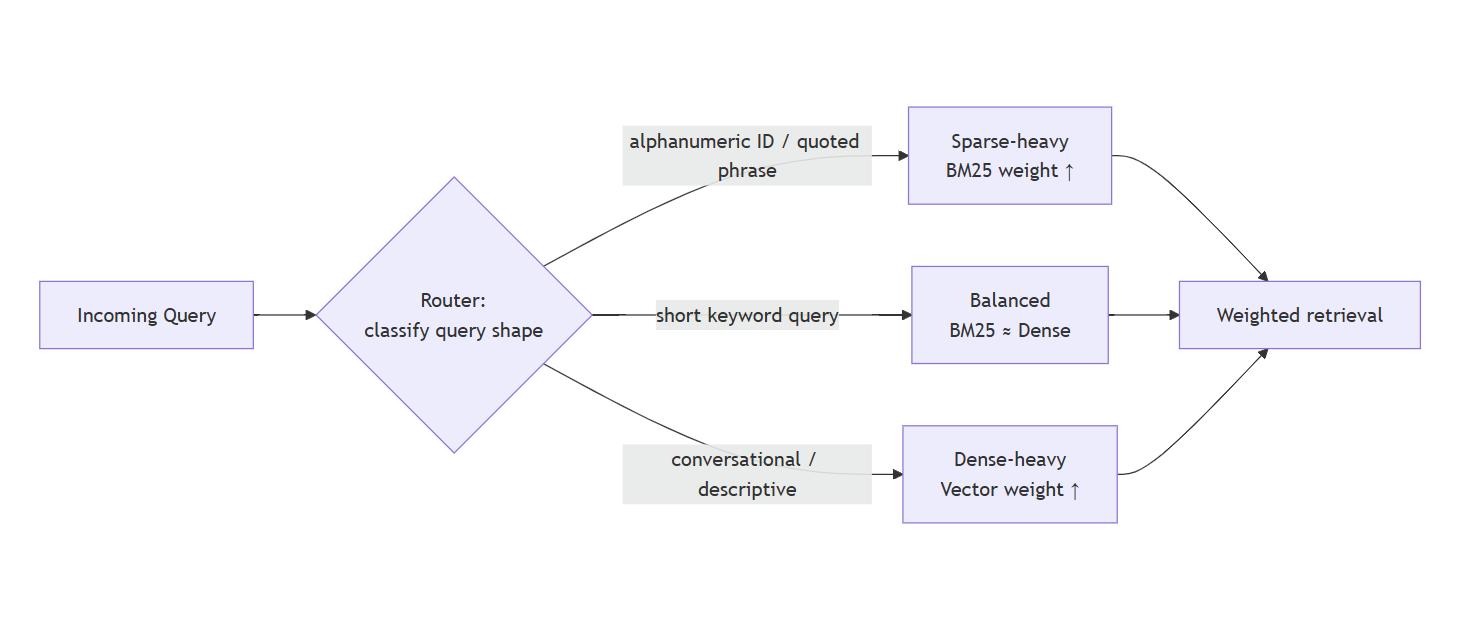


### Practical Application — IT Helpdesk Search

An internal IT helpdesk knowledge base fields two very different query shapes from the same user population: `"VPN error 691"` and `"how do I connect to the office wifi from home"`. The first is a near-exact string lookup — there is no paraphrase to understand, only a code to find. The second is entirely intent-driven with no fixed terminology. A single retrieval configuration tuned for one query shape actively underperforms on the other: a dense-only pipeline wastes its semantic strength on an error code it should just be pattern-matching, while a sparse-only pipeline fails completely the moment a user describes their problem in their own words instead of using the exact phrase from the runbook.

### Example

**Task:** Build a deterministic query router that inspects an incoming query string and returns sparse/dense retrieval weights, then verify it against a small labeled test set.

In [5]:
import re

ALPHANUMERIC_ID_PATTERN = re.compile(r"[A-Z]{1,5}[-#]\d{2,}[A-Za-z0-9-]*")
QUOTED_PHRASE_PATTERN = re.compile(r'"[^"]+"')

def route_query(query: str) -> dict:
    """
    Returns a dict of retrieval weights and the reason the router chose them.
    Weights are floats between 0 and 1 and always sum to 1.0.
    """
    if QUOTED_PHRASE_PATTERN.search(query):
        return {"sparse_weight": 0.85, "dense_weight": 0.15, "reason": "quoted_phrase"}

    if ALPHANUMERIC_ID_PATTERN.search(query):
        return {"sparse_weight": 0.70, "dense_weight": 0.30, "reason": "alphanumeric_id"}

    word_count = len(query.split())
    if word_count <= 3:
        return {"sparse_weight": 0.55, "dense_weight": 0.45, "reason": "short_query"}

    return {"sparse_weight": 0.25, "dense_weight": 0.75, "reason": "conversational"}


# --- verification against a small labeled test set ---
test_cases = [
    ("VPN-691 error code",                                "alphanumeric_id"),
    ("SKU-88213-BLK",                                     "alphanumeric_id"),
    ('search for "annual leave policy"',                  "quoted_phrase"),
    ("printer offline",                                   "short_query"),
    ("how do I connect to the office wifi from home",     "conversational"),
]

correct = 0
for query, expected_reason in test_cases:
    result = route_query(query)
    status = "PASS" if result["reason"] == expected_reason else "FAIL"
    correct += (status == "PASS")
    print(f"[{status}] '{query}' -> {result}")

print(f"\nAccuracy: {correct}/{len(test_cases)}")


[PASS] 'VPN-691 error code' -> {'sparse_weight': 0.7, 'dense_weight': 0.3, 'reason': 'alphanumeric_id'}
[PASS] 'SKU-88213-BLK' -> {'sparse_weight': 0.7, 'dense_weight': 0.3, 'reason': 'alphanumeric_id'}
[PASS] 'search for "annual leave policy"' -> {'sparse_weight': 0.85, 'dense_weight': 0.15, 'reason': 'quoted_phrase'}
[PASS] 'printer offline' -> {'sparse_weight': 0.55, 'dense_weight': 0.45, 'reason': 'short_query'}
[PASS] 'how do I connect to the office wifi from home' -> {'sparse_weight': 0.25, 'dense_weight': 0.75, 'reason': 'conversational'}

Accuracy: 5/5


Running this prints a PASS/FAIL line per test case and a final accuracy score — with the heuristics above, all five cases pass. The important takeaway is not the specific regex, but the pattern: **routing logic should be unit-tested exactly like any other piece of business logic**, because a silent regression here (say, a code change that stops detecting quoted phrases) degrades search quality without throwing an exception anywhere.

### Now you try - Exercise 1.1 — Extend the Query Router

**Task:** Extend `route_query` to correctly handle a fourth query shape that the current heuristics misclassify: **date-range or numeric-range queries**, such as `"orders placed between March and June"` or `"tickets older than 30 days"`. These queries are conversational in surface form (long, no quotes, no obvious ID pattern) but actually need a **metadata pre-filter** (a date range) applied *before* either sparse or dense search runs — routing them purely toward "dense-heavy" retrieval, as the current heuristics would, misses the filtering opportunity entirely.

Your extended router should:

1. Detect date-range and numeric-range language in the query (e.g., "between X and Y", "older than N days", "in the last N months").
2. Return an additional field, `"requires_prefilter": True`, along with an extracted filter description (it does not need to be a fully parsed date — a structured hint like `{"type": "relative_days", "operator": "gt", "value": 30}` is enough).
3. Fall through to the existing four-category logic for everything else, unchanged.
4. Pass a test set of at least 6 cases, including at least 2 that should **not** trigger the new pre-filter path, to confirm you haven't introduced false positives.

In [6]:
import re

# Existing patterns may already be defined elsewhere in the notebook.
QUOTED_PHRASE_PATTERN = re.compile(r'["“][^"”]+["”]')
ALPHANUMERIC_ID_PATTERN = re.compile(
    r"\b(?=[A-Za-z0-9-]*[A-Za-z])(?=[A-Za-z0-9-]*\d)[A-Za-z0-9]+(?:-[A-Za-z0-9]+)+\b"
)

MONTHS = (
    r"January|February|March|April|May|June|July|August|"
    r"September|October|November|December|"
    r"Jan|Feb|Mar|Apr|Jun|Jul|Aug|Sep|Sept|Oct|Nov|Dec"
)

RELATIVE_RANGE_PATTERN = re.compile(
    r"""
    \b(?:
        (?P<comparison>older|newer|more|less)\s+than\s+
        (?P<comparison_value>\d+)\s*
        (?P<comparison_unit>days?|weeks?|months?|years?)
      |
        (?:in|within|during|from)?\s*(?:the\s+)?
        (?P<direction>last|past|next)\s+
        (?P<relative_value>\d+)\s*
        (?P<relative_unit>days?|weeks?|months?|years?)
    )\b
    """,
    re.IGNORECASE | re.VERBOSE,
)

MONTH_RANGE_PATTERN = re.compile(
    rf"\bbetween\s+(?P<start>{MONTHS})\s+and\s+(?P<end>{MONTHS})\b",
    re.IGNORECASE,
)

NUMERIC_RANGE_PATTERN = re.compile(
    r"\bbetween\s+(?P<start>\d+(?:\.\d+)?)\s+and\s+"
    r"(?P<end>\d+(?:\.\d+)?)\b",
    re.IGNORECASE,
)


def extract_filter_hint(query: str):
    """Return a structured range hint, or None when no range is detected."""

    match = RELATIVE_RANGE_PATTERN.search(query)
    if match:
        groups = match.groupdict()

        if groups["comparison"]:
            comparison = groups["comparison"].lower()
            operator = {
                "older": "gt",
                "more": "gt",
                "newer": "lt",
                "less": "lt",
            }[comparison]

            return {
                "type": f"relative_{groups['comparison_unit'].lower().rstrip('s')}",
                "operator": operator,
                "value": int(groups["comparison_value"]),
            }

        direction = groups["direction"].lower()
        return {
            "type": f"relative_{groups['relative_unit'].lower().rstrip('s')}",
            "operator": "within_last" if direction in {"last", "past"} else "within_next",
            "value": int(groups["relative_value"]),
        }

    match = MONTH_RANGE_PATTERN.search(query)
    if match:
        return {
            "type": "date_range",
            "operator": "between",
            "start": match.group("start"),
            "end": match.group("end"),
        }

    match = NUMERIC_RANGE_PATTERN.search(query)
    if match:
        return {
            "type": "numeric_range",
            "operator": "between",
            "start": float(match.group("start")),
            "end": float(match.group("end")),
        }

    return None


def route_query_v2(query: str) -> dict:
    """
    Route a query using the original four-category logic while identifying
    metadata ranges that should be applied before retrieval.
    """
    filter_hint = extract_filter_hint(query)
    requires_prefilter = filter_hint is not None

    # Original routing logic remains unchanged.
    if QUOTED_PHRASE_PATTERN.search(query):
        route = {
            "sparse_weight": 0.85,
            "dense_weight": 0.15,
            "reason": "quoted_phrase",
        }
    elif ALPHANUMERIC_ID_PATTERN.search(query):
        route = {
            "sparse_weight": 0.70,
            "dense_weight": 0.30,
            "reason": "alphanumeric_id",
        }
    elif len(query.split()) <= 3:
        route = {
            "sparse_weight": 0.55,
            "dense_weight": 0.45,
            "reason": "short_query",
        }
    else:
        route = {
            "sparse_weight": 0.25,
            "dense_weight": 0.75,
            "reason": "conversational",
        }

    route.update({
        "requires_prefilter": requires_prefilter,
        "filter_hint": filter_hint,
    })
    return route


In [7]:
# Verification harness -- do not modify. Your implementation above should pass all 6 cases.
test_cases = [
    ("tickets older than 30 days",                        True),
    ("orders placed between March and June",              True),
    ("show me invoices from the past 2 months",            True),
    ("VPN error 691",                                      False),
    ("how do I connect to the office wifi from home",      False),
    ('search for "annual leave policy"',                    False),
]

correct = 0
for query, expected_prefilter in test_cases:
    result = route_query_v2(query)
    status = "PASS" if result["requires_prefilter"] == expected_prefilter else "FAIL"
    correct += (status == "PASS")
    print(f"[{status}] '{query}' -> requires_prefilter={result['requires_prefilter']}, "
          f"filter_hint={result.get('filter_hint')}")

print(f"\nAccuracy: {correct}/{len(test_cases)}")


[PASS] 'tickets older than 30 days' -> requires_prefilter=True, filter_hint={'type': 'relative_day', 'operator': 'gt', 'value': 30}
[PASS] 'orders placed between March and June' -> requires_prefilter=True, filter_hint={'type': 'date_range', 'operator': 'between', 'start': 'March', 'end': 'June'}
[PASS] 'show me invoices from the past 2 months' -> requires_prefilter=True, filter_hint={'type': 'relative_month', 'operator': 'within_last', 'value': 2}
[PASS] 'VPN error 691' -> requires_prefilter=False, filter_hint=None
[PASS] 'how do I connect to the office wifi from home' -> requires_prefilter=False, filter_hint=None
[PASS] 'search for "annual leave policy"' -> requires_prefilter=False, filter_hint=None

Accuracy: 6/6


<h2 id="rag-pipelines"> 1.2 — Designing and Sequencing Multi-Stage Pipelines </h2>

Naive RAG treats retrieval as one monolithic step: embed the query, search the whole index, hand the top-k results to the generator. Production RAG breaks this into four distinct, independently tunable stages, each with a different job and a different failure mode:

| Stage | Optimizes for | Typical failure if skipped |
|---|---|---|
| Pre-filter | Narrowing the search space *before* expensive vector math runs, using metadata (tenant, document type, date, jurisdiction) | Wasted retrieval cycles on irrelevant partitions, or worse, cross-tenant/cross-category data leakage |
| Retrieve | Recall — casting a wide, cheap net across both dense and sparse mechanisms | Missing the right document entirely |
| Rerank | Precision — separating true signal from superficially-similar noise in the candidate set | "Lost in the middle" — the generator can't find the answer buried in 20 mediocre documents |
| Generate | Faithful, grounded synthesis from the refined context | Hallucination when context is thin, contradictory, or diluted |

The sequencing matters as much as the stages themselves. Pre-filtering has to happen *first*, because it changes the search space every downstream stage operates on — running it after retrieval defeats its purpose. Reranking has to happen *after* retrieval, not instead of it, because reranking algorithms (cross-encoders in particular) are too computationally expensive to run over an entire corpus; they are only affordable once retrieval has already narrowed the field to a few dozen candidates.

**Pipeline stage sequence (conceptually):**

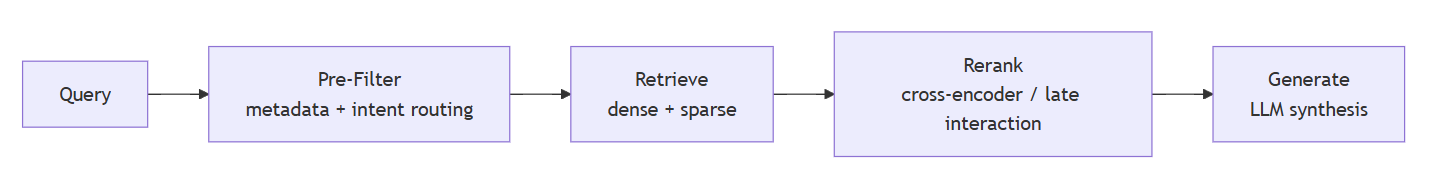

### Practical Application — Legal Research Platform

A legal research tool indexing case law across multiple jurisdictions must pre-filter by jurisdiction and practice area before retrieval, because a semantically similar precedent from the wrong jurisdiction is not just unhelpful — citing it in a brief would be a professional error. The pipeline pre-filters on `{jurisdiction, court_level, practice_area}` metadata, retrieves within that scoped subset using hybrid search (exact citation lookups like "410 U.S. 113" need sparse matching; conceptual research needs dense matching), reranks the candidates for precision, and only then generates a summary — with the generation stage explicitly instructed to cite only documents that survived the pre-filter, never documents from an excluded jurisdiction that a broader search might otherwise have surfaced.

### Example

**Task:** Implement a minimal but complete four-stage pipeline class with an explicit method per stage, and trace a single query through it end-to-end.

In [ ]:
from dataclasses import dataclass, field

@dataclass
class Document:
    doc_id: str
    text: str
    metadata: dict = field(default_factory=dict)
    score: float = 0.0


class MultiStagePipeline:
    """A minimal, explicit four-stage RAG pipeline."""

    def __init__(self, corpus: list):
        self.corpus = corpus

    def pre_filter(self, query: str, tenant_id: str) -> list:
        """Stage 1: narrow the search space using metadata before any search runs."""
        filtered = [d for d in self.corpus if d.metadata.get("tenant_id") == tenant_id]
        print(f"[pre_filter] {len(self.corpus)} docs -> {len(filtered)} docs for tenant '{tenant_id}'")
        return filtered

    def retrieve(self, query: str, candidates: list, top_k: int = 5) -> list:
        """Stage 2: naive keyword-overlap retrieval (stand-in for real hybrid search)."""
        query_terms = set(query.lower().split())
        scored = []
        for doc in candidates:
            overlap = len(query_terms & set(doc.text.lower().split()))
            scored.append(Document(doc.doc_id, doc.text, doc.metadata, score=overlap))
        ranked = sorted(scored, key=lambda d: d.score, reverse=True)[:top_k]
        print(f"[retrieve] top {len(ranked)} candidates by keyword overlap")
        return ranked

    def rerank(self, query: str, candidates: list, top_n: int = 2) -> list:
        """Stage 3: stand-in for a cross-encoder -- here, penalize very short chunks
        that scored well only because they're mostly query terms."""
        rescored = []
        for doc in candidates:
            length_penalty = min(len(doc.text.split()) / 10.0, 1.0)
            rescored.append(Document(doc.doc_id, doc.text, doc.metadata, score=doc.score * length_penalty))
        ranked = sorted(rescored, key=lambda d: d.score, reverse=True)[:top_n]
        print(f"[rerank] refined to top {len(ranked)} candidates")
        return ranked

    def generate(self, query: str, context: list) -> str:
        """Stage 4: stand-in for an LLM call -- concatenates context deterministically."""
        joined = " | ".join(d.text for d in context)
        return f"Answer to '{query}' grounded in: {joined}"

    def run(self, query: str, tenant_id: str) -> str:
        filtered = self.pre_filter(query, tenant_id)
        candidates = self.retrieve(query, filtered)
        top_docs = self.rerank(query, candidates)
        return self.generate(query, top_docs)


corpus_demo = [
    Document("d1", "Reset your password from the account settings page", {"tenant_id": "acme"}),
    Document("d2", "Acme billing cycle runs monthly on the first business day", {"tenant_id": "acme"}),
    Document("d3", "Globex password reset requires admin approval", {"tenant_id": "globex"}),
]

pipeline_demo = MultiStagePipeline(corpus_demo)
answer_demo = pipeline_demo.run("how do I reset my password", tenant_id="acme")
print("\nFinal answer:", answer_demo)


Tracing the output shows the pre-filter immediately dropping the Globex document before retrieval ever sees it — the tenant boundary is enforced structurally, not by hoping the ranking algorithm happens to prefer the right tenant's content.

### Now you try - Exercise 1.2 — Jurisdiction-Aware Legal Pipeline

**Task:** Extend the base four-stage pipeline to support the **legal research** use case from Practical Application. Specifically:

1. Add a `jurisdiction` field to `Document.metadata` and extend `pre_filter` to accept and enforce a `jurisdiction` argument in addition to `tenant_id`.
2. Modify `generate` so that it raises a `ValueError` if any document passed to it does not match the requested jurisdiction — this is a defensive check simulating the real requirement that generation must never cite excluded-jurisdiction material, even if a bug upstream let one slip through.
3. Build a small corpus of at least 5 documents spanning at least 2 jurisdictions, and demonstrate that a query scoped to jurisdiction `"CA"` never surfaces a `"NY"`-only document in the final answer.
4. Print the pre-filter's before/after document counts, exactly as the solved example does, so the effect of your filter is visibly demonstrated.

In [ ]:
from dataclasses import dataclass, field

@dataclass
class Document:
    doc_id: str
    text: str
    metadata: dict = field(default_factory=dict)
    score: float = 0.0


class LegalMultiStagePipeline:
    def __init__(self, corpus: list):
        self.corpus = corpus

    def pre_filter(self, query: str, tenant_id: str, jurisdiction: str = None) -> list:
        # TODO: filter self.corpus by tenant_id AND jurisdiction
        # TODO: print before/after counts like the base pipeline does
        raise NotImplementedError("Implement me")

    def retrieve(self, query: str, candidates: list, top_k: int = 5) -> list:
        query_terms = set(query.lower().split())
        scored = []
        for doc in candidates:
            overlap = len(query_terms & set(doc.text.lower().split()))
            scored.append(Document(doc.doc_id, doc.text, doc.metadata, score=overlap))
        return sorted(scored, key=lambda d: d.score, reverse=True)[:top_k]

    def rerank(self, query: str, candidates: list, top_n: int = 2) -> list:
        rescored = []
        for doc in candidates:
            length_penalty = min(len(doc.text.split()) / 10.0, 1.0)
            rescored.append(Document(doc.doc_id, doc.text, doc.metadata, score=doc.score * length_penalty))
        return sorted(rescored, key=lambda d: d.score, reverse=True)[:top_n]

    def generate(self, query: str, context: list, jurisdiction: str = None) -> str:
        # TODO: raise ValueError if any doc in context doesn't match jurisdiction
        raise NotImplementedError("Implement me")

    def run(self, query: str, tenant_id: str, jurisdiction: str = None) -> str:
        filtered = self.pre_filter(query, tenant_id, jurisdiction)
        candidates = self.retrieve(query, filtered)
        top_docs = self.rerank(query, candidates)
        return self.generate(query, top_docs, jurisdiction)


In [ ]:
# Build a corpus spanning at least 2 jurisdictions and verify isolation.
corpus = [
    Document("d1", "California requires 24 hour notice for tenant entry", {"tenant_id": "firm1", "jurisdiction": "CA"}),
    Document("d2", "California security deposit limit is two months rent", {"tenant_id": "firm1", "jurisdiction": "CA"}),
    Document("d3", "New York requires written notice for lease termination", {"tenant_id": "firm1", "jurisdiction": "NY"}),
    Document("d4", "New York security deposit rules changed in 2019 reform", {"tenant_id": "firm1", "jurisdiction": "NY"}),
    Document("d5", "California eviction moratorium rules during emergencies", {"tenant_id": "firm1", "jurisdiction": "CA"}),
]

pipeline = LegalMultiStagePipeline(corpus)
answer = pipeline.run("what is the security deposit limit", tenant_id="firm1", jurisdiction="CA")
print("\nFinal answer:", answer)
assert "New York" not in answer, "Jurisdiction leak detected!"
print("Jurisdiction isolation verified: no NY content in a CA-scoped answer.")


<h2 id="budgets"> 1.3 — Latency Budgets and System-Level Constraints </h2>

Every production RAG system operates inside a service-level agreement (SLA) — a maximum acceptable end-to-end response time. That total budget does not get spent however you like; it gets **allocated** across the pipeline stages, the same way you would allocate a fixed memory or compute budget across the components of any other system.

A representative allocation for a roughly 1-second end-to-end target:

| Stage | Typical share of budget | Approx. time |
|---|---|---|
| Retrieval (dense + sparse) | 5% | ~50 ms |
| Rerank (cross-encoder) | 15% | ~150 ms |
| Generation (LLM synthesis) | 80% | ~800 ms |

The dominant cost is almost always generation — which is the single most important insight for anyone architecting a latency-sensitive RAG system. It means two things in practice: first, that shaving milliseconds off retrieval has a low ceiling on total impact compared to optimizing generation (streaming responses, using a faster model on the latency-critical path); and second, that when a latency budget is blown, the first place to profile is not always where intuition points.

Latency budgets are not universal constants — they are a product decision, driven by how the answer will actually be consumed. A budget appropriate for a live chat interface is wildly wrong for an asynchronous batch job, and architecting as if one budget fits every use case leads to either over-engineering (burning weeks optimizing latency nobody will notice) or under-engineering (shipping a live-feeling interface with an 8-second response time).

**Budget allocation (conceptually):**

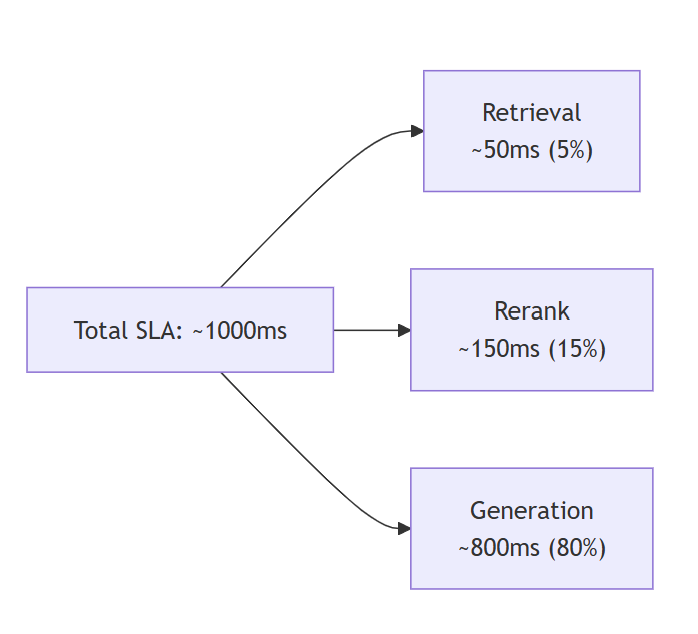

### Practical Application — Live Trading Desk Copilot

A trader asking "what's our current exposure to semiconductor tariffs" mid-call needs an answer in well under two seconds, full stop. This SLA forces concrete architectural trade-offs: smaller local embedding models over larger cloud ones, aggressive candidate pruning before reranking (fewer candidates into the cross-encoder), and a faster (if slightly less capable) generation model. Accuracy still matters — but it is optimized *within* a fixed, non-negotiable latency envelope, not independently of it.

### Example

**Task:** Profile a naive, unoptimized RAG pipeline stage-by-stage using a timing decorator, and compute how far each stage is from its allocated budget.

In [ ]:
import time
import functools

def time_it(stage_name: str, results: dict):
    def decorator(fn):
        @functools.wraps(fn)
        def wrapper(*args, **kwargs):
            start = time.perf_counter()
            result = fn(*args, **kwargs)
            elapsed_ms = (time.perf_counter() - start) * 1000
            results[stage_name] = elapsed_ms
            return result
        return wrapper
    return decorator


naive_timings = {}

class NaiveRAGPipeline:

    @time_it("retrieval", naive_timings)
    def retrieve(self, query: str):
        time.sleep(0.04)   # simulated unoptimized vector search over an unfiltered index
        return [f"doc_{i}" for i in range(20)]

    @time_it("rerank", naive_timings)
    def rerank(self, query: str, docs: list):
        time.sleep(0.31)   # simulated cross-encoder over too many candidates
        return docs[:5]

    @time_it("generation", naive_timings)
    def generate(self, query: str, docs: list):
        time.sleep(0.79)   # simulated LLM call
        return f"Answer to '{query}'"

    def run(self, query: str):
        docs = self.retrieve(query)
        top_docs = self.rerank(query, docs)
        return self.generate(query, top_docs)


BUDGET_MS = {"retrieval": 50, "rerank": 150, "generation": 800}

naive_pipeline = NaiveRAGPipeline()
naive_answer = naive_pipeline.run("what is our refund policy")

print(f"{'Stage':<12}{'Actual (ms)':<14}{'Budget (ms)':<14}{'Over budget?'}")
for stage, actual_ms in naive_timings.items():
    budget_ms = BUDGET_MS[stage]
    over = "YES" if actual_ms > budget_ms else "no"
    print(f"{stage:<12}{actual_ms:<14.1f}{budget_ms:<14}{over}")

total_actual = sum(naive_timings.values())
total_budget = sum(BUDGET_MS.values())
print(f"\nTotal: {total_actual:.1f}ms actual vs {total_budget}ms budget")


Running this reveals the rerank stage (~310ms) is more than double its 150ms allocation — the concrete, isolated engineering problem is "reranking is running over too many candidates," not the vague complaint "the bot feels slow."

### Now you try - Exercise 1.3 — Tune the Pipeline Back Within Budget

**Task:** Given the profiling output above, you've identified that the `rerank` stage is over budget because it is reranking 20 candidates when only 5 are needed downstream. Your task:

1. Modify `retrieve` so it only returns the top 8 candidates (simulating a tighter pre-filter and retrieval cutoff) instead of 20, and modify `rerank`'s simulated latency to scale proportionally with the number of candidates it receives (i.e., its cost is a function of input size, not a fixed sleep).
2. Re-run the profiling harness and confirm `rerank` now falls within its 150ms budget.
3. Write a small `assert_within_budget` helper that raises a clear `AssertionError` if any stage exceeds its allocated budget — this is the seed of a real production latency regression test.
4. Report the new total end-to-end latency and confirm it is under the 1000ms budget ceiling.

In [ ]:
import time
import functools

def time_it(stage_name: str, results: dict):
    def decorator(fn):
        @functools.wraps(fn)
        def wrapper(*args, **kwargs):
            start = time.perf_counter()
            result = fn(*args, **kwargs)
            elapsed_ms = (time.perf_counter() - start) * 1000
            results[stage_name] = elapsed_ms
            return result
        return wrapper
    return decorator


timings = {}

class TunedRAGPipeline:

    @time_it("retrieval", timings)
    def retrieve(self, query: str):
        time.sleep(0.04)
        # TODO: return only 8 candidates instead of 20
        return [f"doc_{i}" for i in range(20)]

    @time_it("rerank", timings)
    def rerank(self, query: str, docs: list):
        # TODO: make simulated latency scale with len(docs) instead of a fixed sleep
        time.sleep(0.31)
        return docs[:5]

    @time_it("generation", timings)
    def generate(self, query: str, docs: list):
        time.sleep(0.79)
        return f"Answer to '{query}'"

    def run(self, query: str):
        docs = self.retrieve(query)
        top_docs = self.rerank(query, docs)
        return self.generate(query, top_docs)


BUDGET_MS = {"retrieval": 50, "rerank": 150, "generation": 800}

def assert_within_budget(timings: dict, budget: dict):
    # TODO: raise AssertionError listing every stage that exceeded its budget
    raise NotImplementedError("Implement me")


In [ ]:
pipeline = TunedRAGPipeline()
answer = pipeline.run("what is our refund policy")

print(f"{'Stage':<12}{'Actual (ms)':<14}{'Budget (ms)':<14}{'Over budget?'}")
for stage, actual_ms in timings.items():
    budget_ms = BUDGET_MS[stage]
    over = "YES" if actual_ms > budget_ms else "no"
    print(f"{stage:<12}{actual_ms:<14.1f}{budget_ms:<14}{over}")

total_actual = sum(timings.values())
total_budget = sum(BUDGET_MS.values())
print(f"\nTotal: {total_actual:.1f}ms actual vs {total_budget}ms budget")

assert_within_budget(timings, BUDGET_MS)
print("All stages within budget.")


# Extensions: Local Models vs. Cloud/API Models

> **The code cells below require either a paid API key (Cloud/API track) or a local model download**

## Extension A — Local Models Approach

**Architecting Robust RAG Pipelines**

The course's labs use pure Python/regex heuristics precisely so they work offline with
zero setup. This section shows how you'd swap in real *local* (self-hosted, no paid API)
tooling once you're ready to go further.

### What Changes, Component by Component

| Course concept | Course's stand-in | Local-model equivalent |
|---|---|---|
| Query routing  | Regex heuristics (`route_query`) | Regex heuristics **or** a small local text-classification model |
| Multi-stage pipeline  | In-memory `Document` list + keyword overlap | `langchain_community.vectorstores.FAISS` + `langchain_community.retrievers.BM25Retriever` |
| Generation stage | `f"Answer to '{query}' grounded in: ..."` string template | A locally-hosted LLM (Ollama, llama.cpp, or a local HuggingFace pipeline) |

### 1. Query Routing — Keep the Heuristics, Optionally Add a Local Classifier

The course's core lesson — that routing is a classification problem solvable with
deterministic heuristics before you need a trained model — still holds locally. If you
want to go further than regex, a **local** intent classifier avoids any API call:

In [ ]:
# OPTIONAL / ILLUSTRATIVE -- requires `transformers` and a model download; not executed here.
from transformers import pipeline

# Runs entirely on your machine after a one-time model download; no API key.
intent_classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
)

def classify_intent_local(query: str) -> str:
    labels = ["exact_id_lookup", "date_range_query", "conversational"]
    result = intent_classifier(query, candidate_labels=labels)
    return result["labels"][0]


**Trade-off:** this adds a real model load (a few hundred MB to a few GB) and CPU
inference latency (tens to hundreds of milliseconds per query) in exchange for
classification that generalizes beyond what your regex patterns anticipated. For most
teams, the course's heuristic router is still the right starting point — reach for this
only once you have evidence the heuristics are misclassifying a meaningful fraction of
real traffic.

### 2. Multi-Stage Pipeline — Real Local Retrieval

In [ ]:
# OPTIONAL / ILLUSTRATIVE -- requires `langchain-huggingface` and `langchain-community`; not executed here.
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_community.retrievers import BM25Retriever

embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

# Pre-filter first, exactly as the course's pipeline sequencing teaches --
# only embed/index the documents that survive the metadata filter.
tenant_docs = [d for d in corpus if d.metadata.get("tenant_id") == tenant_id]

dense_store = FAISS.from_texts(
    [d.text for d in tenant_docs],
    embeddings,
    metadatas=[d.metadata for d in tenant_docs],
)
dense_retriever = dense_store.as_retriever(search_kwargs={"k": 10})

sparse_retriever = BM25Retriever.from_texts([d.text for d in tenant_docs])
sparse_retriever.k = 10


Reranking and fusion for this configuration are covered in the Module 3 extension —
Module 1's job is the pipeline *shape*, not the retrieval algorithm itself.

### 3. Generation — A Local LLM Instead of a String Template

In [ ]:
# OPTIONAL / ILLUSTRATIVE -- requires `langchain-community` and a running local Ollama server; not executed here.
from langchain_community.llms import Ollama

local_llm = Ollama(model="llama3.1:8b")  # requires `ollama pull llama3.1:8b` once, no API key

def generate_local(query: str, context_docs: list) -> str:
    context = "\n".join(d.page_content for d in context_docs)
    prompt = f"Answer the question using only the context below.\n\nContext:\n{context}\n\nQuestion: {query}"
    return local_llm.invoke(prompt)


### What This Buys You, and What It Costs

**Pros of the local approach for this module's lessons:**
- No API key, no per-call cost, no rate limits — you can run the multi-tenant isolation test from Exercise 2 as many times as you want without a bill
- Fully deterministic if you fix the model's random seed, which keeps the spirit of the course's `assert`-based verification intact
- No network dependency once models are downloaded — the pipeline keeps working on a plane

**Cons to budget for:**
- A real download requirement (embedding model + LLM weights) that the course's zero-setup labs deliberately avoid
- Meaningfully slower generation on CPU-only hardware — this directly changes Module 1's latency budget math. A local 8B-parameter model on a laptop CPU can easily take several seconds per response, blowing through the ~800ms generation budget the course's `NaiveRAGPipeline` example targets. On local hardware, treat the entire latency budget table as needing re-derivation against your own measured hardware, not the course's illustrative numbers.
- Quality is usually lower than a frontier hosted model, which matters more for generation than for retrieval

### Bridging Back to the Course

The pipeline *sequencing* lesson (pre-filter → retrieve → rerank → generate) and the
*latency budgeting* discipline (measure, don't assume) both transfer directly. What
changes is only the concrete numbers — profile your own stages with the course's
`time_it` decorator against these real local components rather than assuming the
course's simulated timings apply.

---

## Extension B — Cloud/API Models Approach

**Architecting Robust RAG Pipelines**

The course's labs use pure Python/regex heuristics precisely so they work offline with
zero setup, zero cost, and zero rate-limit risk for a live cohort. This section shows
how you'd swap in real *cloud/API* tooling once you're ready to go further.

### What Changes, Component by Component

| Course concept | Course's stand-in | Cloud/API equivalent |
|---|---|---|
| Query routing  | Regex heuristics (`route_query`) | Structured-output classification via `ChatOpenAI` + `pydantic` |
| Multi-stage pipeline  | In-memory `Document` list + keyword overlap | `FAISS` (still local storage) with `OpenAIEmbeddings` for the vectors themselves |
| Generation stage | `f"Answer to '{query}' grounded in: ..."` string template | `langchain_openai.ChatOpenAI` (e.g. `gpt-4o-mini`) |

### 1. Query Routing — Structured Output Instead of Regex

In [ ]:
# OPTIONAL / ILLUSTRATIVE -- requires `langchain-openai`, `pydantic`, and a funded OPENAI_API_KEY; not executed here.
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field

class RouteDecision(BaseModel):
    reason: str = Field(description="One of: alphanumeric_id, quoted_phrase, relative_range, conversational")
    requires_prefilter: bool = Field(description="True if the query implies a date/numeric range filter")
    sparse_weight: float = Field(description="0-1 weight for sparse retrieval")
    dense_weight: float = Field(description="0-1 weight for dense retrieval")

router_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0).with_structured_output(RouteDecision)

router_prompt = ChatPromptTemplate.from_template(
    "Classify this search query for a retrieval router: {query}"
)

def route_query_cloud(query: str) -> dict:
    decision = router_llm.invoke(router_prompt.format(query=query))
    return decision.model_dump()


**Trade-off:** this is strictly more flexible than regex — it will correctly classify
phrasings the course's patterns never anticipated — but every single query now costs a
network round trip and a token-billed API call, and `temperature=0` reduces but does not
eliminate output variance. The course deliberately avoids this for its labs because a
cohort of ~25 people all calling this per-query router simultaneously is a realistic way
to hit rate limits mid-exercise — exactly the concern flagged in Module 4's Ragas
exercise about `429` errors under batch load.

### 2. Multi-Stage Pipeline — Cloud Embeddings, Local Index

In [ ]:
# OPTIONAL / ILLUSTRATIVE -- requires `langchain-openai`, `langchain-community`, and a funded OPENAI_API_KEY; not executed here.
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

tenant_docs = [d for d in corpus if d.metadata.get("tenant_id") == tenant_id]
dense_store = FAISS.from_texts(
    [d.text for d in tenant_docs],
    embeddings,
    metadatas=[d.metadata for d in tenant_docs],
)


Note that FAISS itself is still a local, in-process index either way — "cloud" here
refers to where the *embedding computation* happens, not where vectors are stored. If
you want a fully managed cloud vector store as well (removing local index management
entirely), refer to - Pinecone, Weaviate Cloud, etc.

### 3. Generation — A Real Hosted LLM

In [ ]:
# OPTIONAL / ILLUSTRATIVE -- requires `langchain-openai` and a funded OPENAI_API_KEY; not executed here.
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

generator = ChatOpenAI(model="gpt-4o-mini", temperature=0)
generation_prompt = ChatPromptTemplate.from_template(
    "Answer the question using only the context below.\n\nContext:\n{context}\n\nQuestion: {query}"
)
generation_chain = generation_prompt | generator | StrOutputParser()

def generate_cloud(query: str, context_docs: list) -> str:
    context = "\n".join(d.page_content for d in context_docs)
    return generation_chain.invoke({"context": context, "query": query})


### What This Buys You, and What It Costs

**Pros of the cloud approach for Module 1's lessons:**
- No local hardware or model-download requirement — works identically on any laptop
- Highest-quality routing and generation available, closest to what you'll actually ship
- Zero maintenance of local model weights or GPU drivers

**Cons to budget for — all directly relevant to what Module 1 teaches:**
- **Latency budgeting gets harder, not easier.** The course's illustrative ~800ms generation budget assumed a fast hosted model; real network latency, provider-side queueing, and token-by-token generation time all now count against that budget, and vary run to run in a way the course's deterministic `time.sleep()` stand-ins never do. Re-profile with the course's `time_it` decorator against your real endpoint before trusting any budget number.
- **Rate limits are a first-class system constraint now**, not a footnote. A router or generator call per query, multiplied by concurrent users, is exactly the kind of load Module 4 warns about hitting `429` errors under.
- **Cost accrues per call.** Routing every query through an LLM (rather than free regex) adds a real, ongoing line item that scales with traffic — worth weighing against the marginal accuracy gain over the heuristic router for your actual query distribution.
- **Non-determinism** means the multi-tenant isolation assertion from Exercise 2 (`assert "New York" not in answer`) is still valid as a hard safety check, but softer correctness checks elsewhere may need to tolerate wording variance across runs.

### Bridging Back to the Course

The pipeline *sequencing* lesson and the discipline of *measuring* a latency budget
rather than assuming one both transfer directly — arguably they matter **more** once
real network calls are in the loop, not less. What changes is that Module 1's
"generation dominates the budget" finding becomes even more pronounced with a real
hosted model, and the router itself now has a real cost/latency profile worth including
in that budget, which the course's free heuristic router never needed to account for.